In [13]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


# 08-04. Final Nested HPO on Selected External Features — Colab GPU
## CatBoost vs MLP — Feature Set 고정 후 마지막 튜닝

이 버전은 기존 08-04의 검증 구조를 유지하면서
**Google Colab GPU에서 실행하기 쉽게 수정한 버전**입니다.

### Colab 변경점

- Google Drive 자동 마운트
- `catboost`, `optuna` 설치 셀 추가
- CUDA 자동 감지
- CatBoost GPU 자동 사용
- PyTorch MLP CUDA 자동 사용
- 입력/결과 경로를 Google Drive 기준으로 관리
- Colab 연결 종료에 대비해 결과를 Drive에 저장
- `FAST_COLAB_MODE=True`이면 trial 수를 15로 낮춰 먼저 실행 가능

> 검증 구조는 기존 08-04와 동일합니다.
> Outer Validation은 Optuna가 직접 보지 않습니다.

---

## 먼저 할 일

Colab 메뉴에서:

```text
런타임
→ 런타임 유형 변경
→ 하드웨어 가속기: GPU
```

를 선택한 뒤 이 Notebook을 실행하세요.

# Colab Setup

## 1. Google Drive 준비

Google Drive에 아래 구조를 만드는 것을 권장합니다.

```text
MyDrive/
└─ next_season_goal_prediction/
   └─ artifacts/
      ├─ 08_v2_preseason_player_snapshot_dev.csv
      ├─ 08_03_model_revalidation_summary.csv
      └─ 08_03_model_revalidation_results.csv
```

필수 파일은:

```text
08_v2_preseason_player_snapshot_dev.csv
```

하나입니다.

08-03의 summary/results는 이전 결과 비교용이므로 없어도 HPO 자체는 실행됩니다.

In [14]:
# Colab에서만 실행
try:
    from google.colab import drive

    drive.mount(
        "/content/drive"
    )

    IN_COLAB = True

except ImportError:
    IN_COLAB = False

print(
    "IN_COLAB:",
    IN_COLAB
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True


In [15]:
# Colab 기본 런타임에는 일부 패키지가 없을 수 있으므로 설치
# 설치 후 보통 별도 재시작 없이 import 가능합니다.

if IN_COLAB:
    !pip -q install optuna catboost

In [16]:
# GPU 확인
if IN_COLAB:
    !nvidia-smi

Mon Aug 10 03:39:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. 프로젝트 경로

아래 `COLAB_PROJECT_DIR`만 본인의 Drive 구조에 맞게 바꾸면 됩니다.

기본값:

```text
/content/drive/MyDrive/next_season_goal_prediction
```

결과도 같은 프로젝트의 `artifacts/`에 저장됩니다.

In [17]:
from pathlib import Path

if IN_COLAB:
    COLAB_PROJECT_DIR = Path(
        "/content/drive/MyDrive/next_season_goal_prediction"
    )

    COLAB_ARTIFACT_DIR = (
        COLAB_PROJECT_DIR
        / "artifacts"
    )

    COLAB_ARTIFACT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "Colab project:",
        COLAB_PROJECT_DIR
    )

    print(
        "Artifacts:",
        COLAB_ARTIFACT_DIR
    )

else:
    COLAB_PROJECT_DIR = None
    COLAB_ARTIFACT_DIR = None

Colab project: /content/drive/MyDrive/next_season_goal_prediction
Artifacts: /content/drive/MyDrive/next_season_goal_prediction/artifacts


## 0. Trial 수

07에서는 모델별 15 trials를 사용했습니다.

이번에는 Feature Set을 이미 확정했기 때문에
조금 더 집중해서 기본값을 **20 trials/model/fold**로 둡니다.

계산량이 너무 크다면:

```python
N_TRIALS_CATBOOST = 15
N_TRIALS_MLP = 15
```

까지 낮추는 것은 괜찮습니다.

단:

- Outer Fold 수는 줄이지 않음
- Inner Fold 수는 줄이지 않음
- Outer Validation을 tuning에 사용하지 않음

이 세 가지는 유지합니다.

In [18]:
from pathlib import Path
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings("ignore")

SEED = 42

# Colab에서 먼저 빠르게 검증하려면 True
FAST_COLAB_MODE = True

if FAST_COLAB_MODE:
    N_TRIALS_CATBOOST = 15
    N_TRIALS_MLP = 15
else:
    N_TRIALS_CATBOOST = 20
    N_TRIALS_MLP = 20

N_INNER_FOLDS = 3

CATBOOST_MAX_ITER = 2000
CATBOOST_PATIENCE = 50

MLP_MAX_EPOCHS = 120
MLP_PATIENCE = 12


def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)


reset_seed()

print("Seed:", SEED)
print("CatBoost trials:", N_TRIALS_CATBOOST)
print("MLP trials:", N_TRIALS_MLP)
print("Inner folds:", N_INNER_FOLDS)

Seed: 42
CatBoost trials: 15
MLP trials: 15
Inner folds: 3


## 1. 라이브러리 확인

In [19]:
try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner

    optuna.logging.set_verbosity(
        optuna.logging.WARNING
    )

    print("optuna:", optuna.__version__)

except ImportError as exc:
    raise ImportError(
        "optuna가 필요합니다. `pip install optuna` 후 "
        "커널을 재시작하세요."
    ) from exc


try:
    import catboost
    from catboost import CatBoostRegressor

    print("catboost:", catboost.__version__)

except ImportError as exc:
    raise ImportError(
        "catboost가 필요합니다."
    ) from exc


try:
    import torch
    import torch.nn as nn

    from torch.utils.data import (
        DataLoader,
        TensorDataset,
    )

    print("torch:", torch.__version__)

except ImportError as exc:
    raise ImportError(
        "PyTorch가 필요합니다."
    ) from exc


DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


USE_GPU = (
    DEVICE == "cuda"
)

CATBOOST_DEVICE_PARAMS = (
    {
        "task_type": "GPU",
        "devices": "0",
    }
    if USE_GPU
    else {
        "task_type": "CPU",
    }
)

print(
    "CatBoost device:",
    CATBOOST_DEVICE_PARAMS
)

if USE_GPU:
    print(
        "✅ CatBoost와 MLP 모두 GPU 사용"
    )
else:
    print(
        "⚠️ GPU가 감지되지 않았습니다. "
        "Colab 런타임 유형을 GPU로 변경하세요."
    )


def reset_torch_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )

optuna: 4.9.0
catboost: 1.2.10
torch: 2.11.0+cu128
Device: cuda
CatBoost device: {'task_type': 'GPU', 'devices': '0'}
✅ CatBoost와 MLP 모두 GPU 사용


# Part A. Data

## 2. 파일 자동 탐색

필수:

```text
08_v2_preseason_player_snapshot_dev.csv
```

선택:

```text
08_03_model_revalidation_summary.csv
08_03_model_revalidation_results.csv
```

선택 파일이 있으면 마지막에 08-03 baseline과 직접 비교합니다.

In [20]:
# --------------------------------------------------------------
# Colab: Drive의 artifacts 폴더를 직접 사용
# Local: 기존 자동 탐색 사용
# --------------------------------------------------------------

if IN_COLAB:
    MANUAL_SNAPSHOT_PATH = (
        COLAB_ARTIFACT_DIR
        / "08_v2_preseason_player_snapshot_dev.csv"
    )

    MANUAL_08_03_SUMMARY_PATH = (
        COLAB_ARTIFACT_DIR
        / "08_03_model_revalidation_summary.csv"
    )

    MANUAL_08_03_RESULTS_PATH = (
        COLAB_ARTIFACT_DIR
        / "08_03_model_revalidation_results.csv"
    )

else:
    MANUAL_SNAPSHOT_PATH = None
    MANUAL_08_03_SUMMARY_PATH = None
    MANUAL_08_03_RESULTS_PATH = None


SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

SEARCH_ROOTS = list(
    dict.fromkeys(
        p.resolve()
        for p in SEARCH_ROOTS
        if p.exists()
    )
)


def find_named_file(filename):
    candidates = []

    for root in SEARCH_ROOTS:
        try:
            for path in root.rglob(
                filename
            ):
                if path.is_file():
                    candidates.append(path)

        except (
            PermissionError,
            OSError,
        ):
            continue

    if not candidates:
        return None

    candidates.sort(
        key=lambda p: (
            len(str(p)),
            str(p),
        )
    )

    return candidates[0]


def resolve_path(
    manual,
    filename,
    required=True,
):
    if manual is not None:
        path = Path(manual)

        if path.exists():
            return path

        if required:
            raise FileNotFoundError(
                f"파일이 없습니다: {path}\n"
                "Google Drive의 artifacts 폴더에 파일을 넣었는지 확인하세요."
            )

        return None

    path = find_named_file(
        filename
    )

    if (
        required
        and path is None
    ):
        raise FileNotFoundError(
            f"{filename}을 찾지 못했습니다."
        )

    return path


SNAPSHOT_PATH = resolve_path(
    MANUAL_SNAPSHOT_PATH,
    "08_v2_preseason_player_snapshot_dev.csv",
)

SUMMARY_08_03_PATH = resolve_path(
    MANUAL_08_03_SUMMARY_PATH,
    "08_03_model_revalidation_summary.csv",
    required=False,
)

RESULTS_08_03_PATH = resolve_path(
    MANUAL_08_03_RESULTS_PATH,
    "08_03_model_revalidation_results.csv",
    required=False,
)

print(
    "Snapshot:",
    SNAPSHOT_PATH
)

print(
    "08-03 summary:",
    SUMMARY_08_03_PATH
)

print(
    "08-03 results:",
    RESULTS_08_03_PATH
)

Snapshot: /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_v2_preseason_player_snapshot_dev.csv
08-03 summary: /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_03_model_revalidation_summary.csv
08-03 results: /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_03_model_revalidation_results.csv


In [21]:
df = pd.read_csv(
    SNAPSHOT_PATH,
    low_memory=False,
)

print("Raw shape:", df.shape)

if SUMMARY_08_03_PATH is not None:
    previous_summary = pd.read_csv(
        SUMMARY_08_03_PATH
    )

    print("\n08-03 summary")
    display(
        previous_summary
    )

Raw shape: (23353, 114)

08-03 summary


,model,experiment,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean
0,Frozen_07_Tuned_MLP,S0_Exp9Cb,4,2.373839,0.056054,2.440085,3.518018,0.432051,-0.477164,7.278375,-7.122766,10.022449,12.751899,2.559621,-0.350568,2.338424
1,Fixed_CatBoost,S3_selected_no_economics,4,2.382645,0.078475,2.458011,3.424914,0.461745,-0.010918,6.415246,-5.972970,8.645465,10.902247,2.721635,0.034598,2.333862
2,Fixed_CatBoost,S4_all_with_economics,4,2.385486,0.076357,2.460112,3.440263,0.456895,-0.005282,6.426842,-5.963972,8.684922,11.043590,2.761516,0.033642,2.332315
3,Fixed_CatBoost,S1_market,4,2.390787,0.077266,2.471609,3.428409,0.460707,-0.013283,6.438716,-5.968845,8.631400,10.941671,2.752900,0.114147,2.339925
4,Fixed_CatBoost,S2_transfer_new_team,4,2.392630,0.080826,2.478733,3.449802,0.453835,-0.009844,6.430194,-5.969466,8.615334,10.997648,2.740936,0.025262,2.342996
5,Fixed_CatBoost,S0_Exp9Cb,4,2.398809,0.074314,2.481577,3.444533,0.455485,-0.011564,6.445676,-5.964375,8.671721,11.098047,2.756612,0.106929,2.348008
6,Frozen_07_Tuned_MLP,S3_selected_no_economics,4,2.450662,0.092464,2.537065,3.520726,0.430944,0.005236,6.421301,-5.872459,8.516003,10.922712,2.812920,0.118744,2.401817


## 3. Exp9Cb Historical Feature 재생성

In [22]:
df["season_start"] = (
    df["season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df["target_year"] = (
    df["target_season"]
    .astype(str)
    .str[:4]
    .astype(int)
)

df = (
    df
    .sort_values(
        [
            "player",
            "season_start",
        ]
    )
    .reset_index(drop=True)
)

player_group = (
    df.groupby(
        "player",
        sort=False,
    )
)

df[
    "goals_3yr_mean"
] = player_group[
    "goals"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_per90_3yr_mean"
] = player_group[
    "goals_per90"
].transform(
    lambda s:
        s.shift(1)
        .rolling(
            window=3,
            min_periods=1,
        )
        .mean()
)

df[
    "goals_3yr_max"
] = player_group[
    "goals"
].transform(
        lambda s:
            s.shift(1)
            .rolling(
                window=3,
                min_periods=1,
            )
            .max()
)

HISTORICAL_COLS = [
    "goals_3yr_mean",
    "goals_per90_3yr_mean",
    "goals_3yr_max",
]

df[
    HISTORICAL_COLS
] = (
    df[
        HISTORICAL_COLS
    ]
    .fillna(0.0)
)

## 4. Model B 모집단 + 2017+

In [23]:
model_df = (
    df[
        df[
            "matched_next"
        ].eq(True)
        & df[
            "target_year"
        ].ge(2017)
    ]
    .copy()
)

model_df = (
    model_df
    .sort_values(
        [
            "season_start",
            "player",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Rows:",
    len(model_df),
)

print(
    "Season range:",
    model_df[
        "season"
    ].min(),
    "~",
    model_df[
        "season"
    ].max(),
)

print(
    "Target mean:",
    model_df[
        "next_goals"
    ].mean(),
)

print(
    "Changed-team rate:",
    f"{model_df['changed_team_preseason'].mean():.2%}"
)

Rows: 6371
Season range: 2016-2017 ~ 2023-2024
Target mean: 3.782608695652174
Changed-team rate: 9.98%


## 5. Final Test Lock

In [24]:
LOCKED_TEST_INPUT_SEASON = (
    "2024-2025"
)

LOCKED_TEST_TARGET_SEASON = (
    "2025-2026"
)

assert (
    LOCKED_TEST_INPUT_SEASON
    not in set(
        model_df[
            "season"
        ].astype(str)
    )
)

print(
    "✅ Final Test remains locked:",
    LOCKED_TEST_INPUT_SEASON,
    "→",
    LOCKED_TEST_TARGET_SEASON,
)

✅ Final Test remains locked: 2024-2025 → 2025-2026


# Part B. Final Selected Feature Set

In [25]:
BASE_NUMERIC = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90",
]

TEAM_BASE_FEATURES = [
    "old_team_rank_pct",
    "old_team_points_per_game",
    "old_team_goal_diff_per_game",
]

EXP9CB_NUMERIC = (
    BASE_NUMERIC
    + HISTORICAL_COLS
    + TEAM_BASE_FEATURES
)

MARKET_VALUE_FEATURES = [
    "market_value_known",
    "log_market_value",
    "market_value_percentile",
    "market_value_vs_position_median",
]

MARKET_MOMENTUM_FEATURES = [
    "market_value_growth_6m",
    "market_value_growth_12m",
    "market_value_vs_peak",
]

TRANSFER_STATE_FEATURES = [
    "changed_team_preseason",
    "same_league_transfer",
    "league_changed",
    "country_changed",
    "is_loan_preseason",
    "days_since_transfer",
]

NEW_TEAM_ENVIRONMENT_FEATURES = [
    "new_team_prev_rank_pct",
    "new_team_prev_points_per_game",
    "new_team_prev_goal_diff_per_game",
    "team_rank_change",
    "team_points_change",
    "team_goal_diff_change",
    "new_team_strength_missing",
]

SELECTED_EXTERNAL = (
    MARKET_VALUE_FEATURES
    + MARKET_MOMENTUM_FEATURES
    + TRANSFER_STATE_FEATURES
    + NEW_TEAM_ENVIRONMENT_FEATURES
)

FINAL_NUMERIC = (
    EXP9CB_NUMERIC
    + SELECTED_EXTERNAL
)

FINAL_CATEGORICAL = [
    "league",
    "position_group",
]

FEATURE_COLS = (
    FINAL_NUMERIC
    + FINAL_CATEGORICAL
)

TARGET = "next_goals"

print(
    "Final numeric:",
    len(FINAL_NUMERIC),
)

print(
    "Categorical:",
    len(FINAL_CATEGORICAL),
)

print(
    "Raw feature count:",
    len(FEATURE_COLS),
)

print("\nExcluded Economics:")
for c in [
    "transfer_fee_known",
    "log_transfer_fee",
    "fee_to_transfer_market_value_ratio",
]:
    print(" -", c)

Final numeric: 37
Categorical: 2
Raw feature count: 39

Excluded Economics:
 - transfer_fee_known
 - log_transfer_fee
 - fee_to_transfer_market_value_ratio


## 6. Missingness 확인

In [26]:
missingness = (
    model_df[
        FINAL_NUMERIC
    ]
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
    .rename(
        "missing_rate"
    )
    .to_frame()
)

display(
    missingness.head(20)
)

,missing_rate
days_since_transfer,0.873960
market_value_growth_12m,0.058547
market_value_growth_6m,0.054466
market_value_vs_position_median,0.053995
market_value_vs_peak,0.053995
market_value_percentile,0.053995
log_market_value,0.053995
team_rank_change,0.032491
team_goal_diff_change,0.032491
team_points_change,0.032491


# Part C. Temporal Folds

In [27]:
OUTER_VAL_SEASONS = [
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]


def build_inner_folds(
    outer_train_df,
    n_inner_folds=N_INNER_FOLDS,
):
    seasons = sorted(
        outer_train_df[
            "season_start"
        ]
        .dropna()
        .astype(int)
        .unique()
    )

    candidate_val_seasons = [
        season
        for season in seasons
        if (
            outer_train_df[
                "season_start"
            ]
            .lt(season)
            .any()
        )
    ]

    selected_val_seasons = (
        candidate_val_seasons[
            -n_inner_folds:
        ]
    )

    folds = []

    for val_start in (
        selected_val_seasons
    ):
        train_df = (
            outer_train_df[
                outer_train_df[
                    "season_start"
                ]
                < val_start
            ]
            .copy()
        )

        val_df = (
            outer_train_df[
                outer_train_df[
                    "season_start"
                ]
                == val_start
            ]
            .copy()
        )

        if (
            train_df.empty
            or val_df.empty
        ):
            continue

        folds.append({
            "val_season_start": (
                int(val_start)
            ),
            "train_df": train_df,
            "val_df": val_df,
        })

    if len(folds) == 0:
        raise ValueError(
            "Inner Fold를 만들 수 없습니다."
        )

    return folds


for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    val_start = int(
        outer_val_season[:4]
    )

    outer_train_df = (
        model_df[
            model_df[
                "season_start"
            ]
            < val_start
        ]
    )

    inner_folds = (
        build_inner_folds(
            outer_train_df
        )
    )

    print(
        f"Outer Fold {fold_id} "
        f"({outer_val_season})"
    )

    for inner in inner_folds:
        print(
            "  Inner Val:",
            inner[
                "val_season_start"
            ],
            "| Train:",
            len(
                inner[
                    "train_df"
                ]
            ),
            "| Val:",
            len(
                inner[
                    "val_df"
                ]
            ),
        )

Outer Fold 1 (2020-2021)
  Inner Val: 2017 | Train: 832 | Val: 825
  Inner Val: 2018 | Train: 1657 | Val: 807
  Inner Val: 2019 | Train: 2464 | Val: 788
Outer Fold 2 (2021-2022)
  Inner Val: 2018 | Train: 1657 | Val: 807
  Inner Val: 2019 | Train: 2464 | Val: 788
  Inner Val: 2020 | Train: 3252 | Val: 834
Outer Fold 3 (2022-2023)
  Inner Val: 2019 | Train: 2464 | Val: 788
  Inner Val: 2020 | Train: 3252 | Val: 834
  Inner Val: 2021 | Train: 4086 | Val: 778
Outer Fold 4 (2023-2024)
  Inner Val: 2020 | Train: 3252 | Val: 834
  Inner Val: 2021 | Train: 4086 | Val: 778
  Inner Val: 2022 | Train: 4864 | Val: 738


# Part D. Metrics

In [28]:
def regression_metrics(
    y_true,
    y_pred,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    return {
        "mae": (
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "rmse": (
            mean_squared_error(
                y_true,
                y_pred,
            ) ** 0.5
        ),
        "r2": (
            r2_score(
                y_true,
                y_pred,
            )
        ),
        "bias": float(
            np.mean(
                y_pred
                - y_true
            )
        ),
    }


def slice_metrics(
    y_true,
    y_pred,
    mask,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float,
    )

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    if mask.sum() == 0:
        return {
            "n": 0,
            "mae": np.nan,
            "bias": np.nan,
        }

    return {
        "n": int(
            mask.sum()
        ),
        "mae": (
            mean_absolute_error(
                y_true[mask],
                y_pred[mask],
            )
        ),
        "bias": float(
            np.mean(
                y_pred[mask]
                - y_true[mask]
            )
        ),
    }


def add_diagnostics(
    row,
    val_df,
    y_true,
    pred,
):
    for threshold in [
        10,
        15,
        20,
    ]:
        h = slice_metrics(
            y_true,
            pred,
            y_true >= threshold,
        )

        row[
            f"{threshold}plus_n"
        ] = h["n"]

        row[
            f"{threshold}plus_mae"
        ] = h["mae"]

        row[
            f"{threshold}plus_bias"
        ] = h["bias"]

    changed_mask = (
        val_df[
            "changed_team_preseason"
        ]
        .fillna(0)
        .astype(int)
        .eq(1)
        .to_numpy()
    )

    changed = slice_metrics(
        y_true,
        pred,
        changed_mask,
    )

    same_team = slice_metrics(
        y_true,
        pred,
        ~changed_mask,
    )

    row[
        "changed_team_n"
    ] = changed["n"]

    row[
        "changed_team_mae"
    ] = changed["mae"]

    row[
        "changed_team_bias"
    ] = changed["bias"]

    row[
        "same_team_n"
    ] = same_team["n"]

    row[
        "same_team_mae"
    ] = same_team["mae"]

    row[
        "same_team_bias"
    ] = same_team["bias"]

    return row

# Part E. CatBoost Nested HPO

### Colab GPU 주의

CatBoost의 GPU 학습은 CPU 버전과 부동소수점 연산 순서가 달라
**완전히 동일한 seed라도 결과가 아주 조금 달라질 수 있습니다.**

따라서 이번 Colab 결과는:

- 동일한 temporal validation protocol
- 동일한 feature set
- 동일한 Optuna search space

은 유지하지만, CPU에서 나온 소수점 단위 결과와 완전히 같을 필요는 없습니다.

이번 목적은 **최종 후보 모델을 효율적으로 탐색하는 것**입니다.

## 7. CatBoost 데이터 준비

CatBoost는 numeric NaN을 native로 처리합니다.
범주형은 문자열로 유지합니다.

In [29]:
def prepare_catboost_xy(
    data,
):
    X = data[
        FEATURE_COLS
    ].copy()

    for col in (
        FINAL_CATEGORICAL
    ):
        X[col] = (
            X[col]
            .fillna(
                "__MISSING__"
            )
            .astype(str)
        )

    for col in (
        FINAL_NUMERIC
    ):
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce",
        )

    y = (
        data[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    cat_indices = [
        X.columns.get_loc(c)
        for c in (
            FINAL_CATEGORICAL
        )
    ]

    return (
        X,
        y,
        cat_indices,
    )

## 8. CatBoost Search Space

07과 동일한 핵심 Search Space를 사용합니다.

이번에는 Feature가 달라졌기 때문에
같은 범위를 다시 탐색하는 것이 목적입니다.

In [30]:
def suggest_catboost_params(
    trial,
):
    return {
        "depth": (
            trial.suggest_int(
                "depth",
                4,
                8,
            )
        ),

        "learning_rate": (
            trial.suggest_float(
                "learning_rate",
                1e-2,
                0.15,
                log=True,
            )
        ),

        "l2_leaf_reg": (
            trial.suggest_float(
                "l2_leaf_reg",
                1e-2,
                20.0,
                log=True,
            )
        ),

        "random_strength": (
            trial.suggest_float(
                "random_strength",
                1e-3,
                5.0,
                log=True,
            )
        ),

        "bagging_temperature": (
            trial.suggest_float(
                "bagging_temperature",
                0.0,
                2.0,
            )
        ),
    }

## 9. CatBoost Inner Objective

In [31]:
def make_catboost_objective(
    outer_train_df,
    base_seed,
):
    inner_folds = (
        build_inner_folds(
            outer_train_df
        )
    )

    def objective(
        trial,
    ):
        params = (
            suggest_catboost_params(
                trial
            )
        )

        fold_maes = []

        for inner_idx, fold in enumerate(
            inner_folds,
            start=1,
        ):
            (
                X_train,
                y_train,
                cat_indices,
            ) = prepare_catboost_xy(
                fold[
                    "train_df"
                ]
            )

            (
                X_val,
                y_val,
                _,
            ) = prepare_catboost_xy(
                fold[
                    "val_df"
                ]
            )

            model = (
                CatBoostRegressor(
                    iterations=(
                        CATBOOST_MAX_ITER
                    ),
                    loss_function="RMSE",
                    eval_metric="MAE",
                    bootstrap_type="Bayesian",
                    random_seed=(
                        base_seed
                        + inner_idx
                    ),
                    verbose=False,
                    allow_writing_files=False,
                    **CATBOOST_DEVICE_PARAMS,
                    **params,
                )
            )

            model.fit(
                X_train,
                y_train,
                cat_features=(
                    cat_indices
                ),
                eval_set=(
                    X_val,
                    y_val,
                ),
                early_stopping_rounds=(
                    CATBOOST_PATIENCE
                ),
                use_best_model=True,
                verbose=False,
            )

            pred = model.predict(
                X_val
            )

            fold_mae = (
                mean_absolute_error(
                    y_val,
                    pred,
                )
            )

            fold_maes.append(
                fold_mae
            )

            running_mean = float(
                np.mean(
                    fold_maes
                )
            )

            trial.report(
                running_mean,
                step=inner_idx,
            )

            if trial.should_prune():
                raise (
                    optuna.TrialPruned()
                )

        trial.set_user_attr(
            "inner_mae_std",
            float(
                np.std(
                    fold_maes
                )
            ),
        )

        trial.set_user_attr(
            "inner_maes",
            [
                float(x)
                for x in (
                    fold_maes
                )
            ],
        )

        return float(
            np.mean(
                fold_maes
            )
        )

    return objective

## 10. Best CatBoost Params → Outer Train 재학습

Best hyperparameter가 정해진 후에도
iteration 수는 고정하지 않습니다.

Outer Train의 마지막 시즌으로 best iteration을 다시 정한 뒤,
Outer Train 전체로 그 iteration만큼 재학습합니다.

In [32]:
def find_final_catboost_iterations(
    outer_train_df,
    best_params,
    seed,
):
    calibration_val_start = (
        outer_train_df[
            "season_start"
        ].max()
    )

    cal_train = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            < calibration_val_start
        ]
        .copy()
    )

    cal_val = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            == calibration_val_start
        ]
        .copy()
    )

    (
        X_train,
        y_train,
        cat_indices,
    ) = prepare_catboost_xy(
        cal_train
    )

    (
        X_val,
        y_val,
        _,
    ) = prepare_catboost_xy(
        cal_val
    )

    model = (
        CatBoostRegressor(
            iterations=(
                CATBOOST_MAX_ITER
            ),
            loss_function="RMSE",
            eval_metric="MAE",
            bootstrap_type="Bayesian",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            **CATBOOST_DEVICE_PARAMS,
            **best_params,
        )
    )

    model.fit(
        X_train,
        y_train,
        cat_features=(
            cat_indices
        ),
        eval_set=(
            X_val,
            y_val,
        ),
        early_stopping_rounds=(
            CATBOOST_PATIENCE
        ),
        use_best_model=True,
        verbose=False,
    )

    return max(
        1,
        int(
            model.get_best_iteration()
        )
        + 1,
    )


def fit_catboost_best_on_outer_train(
    outer_train_df,
    outer_val_df,
    best_params,
    seed,
):
    selected_iterations = (
        find_final_catboost_iterations(
            outer_train_df,
            best_params,
            seed=seed,
        )
    )

    (
        X_train,
        y_train,
        cat_indices,
    ) = prepare_catboost_xy(
        outer_train_df
    )

    (
        X_val,
        y_val,
        _,
    ) = prepare_catboost_xy(
        outer_val_df
    )

    model = (
        CatBoostRegressor(
            iterations=(
                selected_iterations
            ),
            loss_function="RMSE",
            bootstrap_type="Bayesian",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            **CATBOOST_DEVICE_PARAMS,
            **best_params,
        )
    )

    start = (
        time.perf_counter()
    )

    model.fit(
        X_train,
        y_train,
        cat_features=(
            cat_indices
        ),
        verbose=False,
    )

    pred = model.predict(
        X_val
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_rounds": (
            selected_iterations
        ),
        "fit_seconds": elapsed,
    }

## Colab 실행 중간 저장

Colab 연결이 끊길 가능성을 고려해 각 Outer Fold가 끝날 때
현재까지의 결과를 Drive에 checkpoint로 저장합니다.

In [33]:
def save_checkpoint(
    name,
    data,
):
    if not IN_COLAB:
        return

    checkpoint_dir = (
        COLAB_ARTIFACT_DIR
        / "checkpoints"
    )

    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    path = (
        checkpoint_dir
        / name
    )

    data.to_csv(
        path,
        index=False,
    )

    print(
        "[checkpoint]",
        path
    )

## 11. CatBoost Nested HPO 실행

In [34]:
catboost_outer_results = []
catboost_trial_frames = []
catboost_outer_predictions = []
catboost_best_params_by_fold = {}


for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    outer_val_start = int(
        outer_val_season[:4]
    )

    outer_train_df = (
        model_df[
            model_df[
                "season_start"
            ]
            < outer_val_start
        ]
        .copy()
    )

    outer_val_df = (
        model_df[
            model_df[
                "season_start"
            ]
            == outer_val_start
        ]
        .copy()
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"[CatBoost] Outer Fold {fold_id} | "
        f"{outer_val_season} | "
        f"Train {len(outer_train_df):,} | "
        f"Val {len(outer_val_df):,}"
    )

    print(
        "=" * 90
    )

    sampler = TPESampler(
        seed=(
            SEED
            + fold_id * 1000
        )
    )

    pruner = MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1,
    )

    study = (
        optuna.create_study(
            direction="minimize",
            sampler=sampler,
            pruner=pruner,
            study_name=(
                f"08_04_catboost_"
                f"outer_fold_{fold_id}"
            ),
        )
    )

    objective = (
        make_catboost_objective(
            outer_train_df,
            base_seed=(
                SEED
                + 10000
                + fold_id * 1000
            ),
        )
    )

    study.optimize(
        objective,
        n_trials=(
            N_TRIALS_CATBOOST
        ),
        show_progress_bar=True,
    )

    best_params = (
        study.best_params.copy()
    )

    catboost_best_params_by_fold[
        fold_id
    ] = best_params

    print(
        "Best inner MAE:",
        study.best_value,
    )

    print(
        "Best params:",
        best_params,
    )

    outer_result = (
        fit_catboost_best_on_outer_train(
            outer_train_df,
            outer_val_df,
            best_params,
            seed=(
                SEED
                + 20000
                + fold_id
            ),
        )
    )

    metrics = regression_metrics(
        outer_result[
            "y_true"
        ],
        outer_result[
            "pred"
        ],
    )

    row = {
        "model": (
            "Tuned_CatBoost_S3"
        ),
        "fold": fold_id,
        "outer_val_season": (
            outer_val_season
        ),
        "train_n": len(
            outer_train_df
        ),
        "val_n": len(
            outer_val_df
        ),
        "best_inner_mae": (
            study.best_value
        ),
        "selected_rounds": (
            outer_result[
                "selected_rounds"
            ]
        ),
        "fit_seconds": (
            outer_result[
                "fit_seconds"
            ]
        ),
        **metrics,
    }

    row = add_diagnostics(
        row,
        outer_val_df,
        outer_result[
            "y_true"
        ],
        outer_result[
            "pred"
        ],
    )

    catboost_outer_results.append(
        row
    )

    pred_df = (
        outer_val_df[
            [
                "player",
                "team",
                "league",
                "season",
                "target_season",
                "position_group",
                "goals",
                "next_goals",
                "changed_team_preseason",
                "destination_team",
                "market_value_preseason_eur",
            ]
        ]
        .copy()
    )

    pred_df[
        "model"
    ] = (
        "Tuned_CatBoost_S3"
    )

    pred_df[
        "fold"
    ] = fold_id

    pred_df[
        "prediction"
    ] = outer_result[
        "pred"
    ]

    catboost_outer_predictions.append(
        pred_df
    )

    trials_df = (
        study.trials_dataframe(
            attrs=(
                "number",
                "value",
                "params",
                "state",
                "user_attrs",
            )
        )
    )

    trials_df[
        "outer_fold"
    ] = fold_id

    trials_df[
        "outer_val_season"
    ] = outer_val_season

    catboost_trial_frames.append(
        trials_df
    )

    # Colab 중간 저장
    save_checkpoint(
        "08_04_catboost_outer_results_checkpoint.csv",
        pd.DataFrame(
            catboost_outer_results
        ),
    )

    save_checkpoint(
        "08_04_catboost_trials_checkpoint.csv",
        pd.concat(
            catboost_trial_frames,
            ignore_index=True,
        ),
    )

    print(
        f"Outer MAE: "
        f"{metrics['mae']:.4f} | "
        f"R²: {metrics['r2']:.4f} | "
        f"10+: {row['10plus_mae']:.4f}"
    )


catboost_outer_results = (
    pd.DataFrame(
        catboost_outer_results
    )
)

catboost_trials = (
    pd.concat(
        catboost_trial_frames,
        ignore_index=True,
    )
)

catboost_outer_predictions = (
    pd.concat(
        catboost_outer_predictions,
        ignore_index=True,
    )
)


[CatBoost] Outer Fold 1 | 2020-2021 | Train 3,252 | Val 834


  0%|          | 0/15 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric perio

Best inner MAE: 2.360700065819948
Best params: {'depth': 6, 'learning_rate': 0.016802840707363223, 'l2_leaf_reg': 6.860466437250665, 'random_strength': 0.10123734849571585, 'bagging_temperature': 1.1065721290135575}


Default metric period is 5 because MAE is/are not implemented for GPU


...

  0%|          | 0/15 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric perio

Best inner MAE: 2.35936311340533
Best params: {'depth': 8, 'learning_rate': 0.025622659944134703, 'l2_leaf_reg': 0.013605550327209882, 'random_strength': 4.158180187965457, 'bagging_temperature': 1.9880493918480728}


Default metric period is 5 because MAE is/are not implemented for GPU


[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_catboost_outer_results_checkpoint.csv
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_catboost_trials_checkpoint.csv
Outer MAE: 2.4622 | R²: 0.4510 | 10+: 6.8454


# Part F. MLP Nested HPO

## 12. MLP Preprocessing

External Feature에는 결측치가 있으므로:

```text
Numeric
Train median imputation
→ StandardScaler

Categorical
OneHotEncoder(handle_unknown="ignore")
```

를 사용합니다.

Imputer와 Scaler는 각 Inner/Outer Train에서만 fit됩니다.

In [35]:
def make_mlp_preprocessor():
    numeric_pipeline = (
        Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                FINAL_NUMERIC,
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                FINAL_CATEGORICAL,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def mlp_fit_transform(
    train_df,
    eval_df,
):
    preprocessor = (
        make_mlp_preprocessor()
    )

    X_train = (
        preprocessor.fit_transform(
            train_df[
                FEATURE_COLS
            ]
        )
    )

    X_eval = (
        preprocessor.transform(
            eval_df[
                FEATURE_COLS
            ]
        )
    )

    y_train = (
        train_df[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    y_eval = (
        eval_df[
            TARGET
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    return (
        X_train,
        X_eval,
        y_train,
        y_eval,
        preprocessor,
    )

## 13. MLP Search Space

07과 동일한 architecture 후보를 다시 사용합니다.

이번에는 입력 feature 공간이 달라졌으므로
**같은 search space에서 다른 최적점이 선택되는지** 확인하는 것이 핵심입니다.

In [36]:
MLP_ARCHITECTURES = {
    "64_32": [
        64,
        32,
    ],

    "128_64": [
        128,
        64,
    ],

    "128_64_32": [
        128,
        64,
        32,
    ],

    "256_128_64": [
        256,
        128,
        64,
    ],
}


def suggest_mlp_params(
    trial,
):
    architecture_name = (
        trial.suggest_categorical(
            "architecture",
            list(
                MLP_ARCHITECTURES.keys()
            ),
        )
    )

    return {
        "architecture_name": (
            architecture_name
        ),

        "hidden_dims": (
            MLP_ARCHITECTURES[
                architecture_name
            ]
        ),

        "dropout": (
            trial.suggest_float(
                "dropout",
                0.0,
                0.4,
            )
        ),

        "learning_rate": (
            trial.suggest_float(
                "learning_rate",
                1e-4,
                3e-3,
                log=True,
            )
        ),

        "weight_decay": (
            trial.suggest_float(
                "weight_decay",
                1e-6,
                1e-2,
                log=True,
            )
        ),

        "batch_size": (
            trial.suggest_categorical(
                "batch_size",
                [
                    32,
                    64,
                    128,
                ],
            )
        ),
    }

## 14. Flexible MLP

In [37]:
class FlexibleMLP(
    nn.Module
):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        dropout=0.0,
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in (
            hidden_dims
        ):
            layers.append(
                nn.Linear(
                    prev_dim,
                    hidden_dim,
                )
            )

            layers.append(
                nn.ReLU()
            )

            if dropout > 0:
                layers.append(
                    nn.Dropout(
                        dropout
                    )
                )

            prev_dim = (
                hidden_dim
            )

        layers.append(
            nn.Linear(
                prev_dim,
                1,
            )
        )

        self.net = (
            nn.Sequential(
                *layers
            )
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


def make_loader(
    X,
    y,
    batch_size,
    shuffle=False,
):
    X_t = torch.tensor(
        X,
        dtype=torch.float32,
    )

    y_t = torch.tensor(
        y,
        dtype=torch.float32,
    ).reshape(
        -1,
        1,
    )

    dataset = TensorDataset(
        X_t,
        y_t,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
    )

## 15. MLP Inner Fold 학습

Loss는 MSE지만,
Early Stopping과 HPO 목적함수는 **Validation MAE**입니다.

In [38]:
def train_mlp_inner_fold(
    train_df,
    val_df,
    params,
    seed,
):
    reset_torch_seed(
        seed
    )

    (
        X_train,
        X_val,
        y_train,
        y_val,
        _,
    ) = mlp_fit_transform(
        train_df,
        val_df,
    )

    train_loader = (
        make_loader(
            X_train,
            y_train,
            batch_size=(
                params[
                    "batch_size"
                ]
            ),
            shuffle=True,
        )
    )

    model = FlexibleMLP(
        input_dim=(
            X_train.shape[1]
        ),
        hidden_dims=(
            params[
                "hidden_dims"
            ]
        ),
        dropout=(
            params[
                "dropout"
            ]
        ),
    ).to(
        DEVICE
    )

    criterion = (
        nn.MSELoss()
    )

    optimizer = (
        torch.optim.Adam(
            model.parameters(),
            lr=(
                params[
                    "learning_rate"
                ]
            ),
            weight_decay=(
                params[
                    "weight_decay"
                ]
            ),
        )
    )

    best_mae = float(
        "inf"
    )

    best_epoch = 1
    patience_count = 0

    X_val_t = torch.tensor(
        X_val,
        dtype=torch.float32,
        device=DEVICE,
    )

    for epoch in range(
        1,
        MLP_MAX_EPOCHS + 1,
    ):
        model.train()

        for X_b, y_b in (
            train_loader
        ):
            X_b = X_b.to(
                DEVICE
            )

            y_b = y_b.to(
                DEVICE
            )

            optimizer.zero_grad()

            pred = model(
                X_b
            )

            loss = criterion(
                pred,
                y_b,
            )

            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            val_pred = (
                model(
                    X_val_t
                )
                .cpu()
                .numpy()
                .ravel()
            )

        val_mae = (
            mean_absolute_error(
                y_val,
                val_pred,
            )
        )

        if (
            val_mae
            < best_mae - 1e-8
        ):
            best_mae = (
                val_mae
            )

            best_epoch = (
                epoch
            )

            patience_count = 0

        else:
            patience_count += 1

        if (
            patience_count
            >= MLP_PATIENCE
        ):
            break

    return {
        "best_mae": (
            best_mae
        ),
        "best_epoch": (
            best_epoch
        ),
        "epochs_executed": (
            epoch
        ),
    }

## 16. MLP Optuna Objective

In [39]:
def make_mlp_objective(
    outer_train_df,
    base_seed,
):
    inner_folds = (
        build_inner_folds(
            outer_train_df
        )
    )

    def objective(
        trial,
    ):
        params = (
            suggest_mlp_params(
                trial
            )
        )

        fold_maes = []
        best_epochs = []

        for inner_idx, fold in enumerate(
            inner_folds,
            start=1,
        ):
            result = (
                train_mlp_inner_fold(
                    fold[
                        "train_df"
                    ],
                    fold[
                        "val_df"
                    ],
                    params=params,
                    seed=(
                        base_seed
                        + inner_idx
                    ),
                )
            )

            fold_maes.append(
                result[
                    "best_mae"
                ]
            )

            best_epochs.append(
                result[
                    "best_epoch"
                ]
            )

            running_mean = float(
                np.mean(
                    fold_maes
                )
            )

            trial.report(
                running_mean,
                step=inner_idx,
            )

            if trial.should_prune():
                raise (
                    optuna.TrialPruned()
                )

        trial.set_user_attr(
            "inner_mae_std",
            float(
                np.std(
                    fold_maes
                )
            ),
        )

        trial.set_user_attr(
            "inner_maes",
            [
                float(x)
                for x in (
                    fold_maes
                )
            ],
        )

        trial.set_user_attr(
            "inner_best_epochs",
            [
                int(x)
                for x in (
                    best_epochs
                )
            ],
        )

        return float(
            np.mean(
                fold_maes
            )
        )

    return objective

## 17. Best MLP Params → Outer Train 재학습

In [40]:
def find_final_mlp_epoch(
    outer_train_df,
    best_params,
    seed,
):
    calibration_val_start = (
        outer_train_df[
            "season_start"
        ].max()
    )

    cal_train = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            < calibration_val_start
        ]
        .copy()
    )

    cal_val = (
        outer_train_df[
            outer_train_df[
                "season_start"
            ]
            == calibration_val_start
        ]
        .copy()
    )

    result = (
        train_mlp_inner_fold(
            cal_train,
            cal_val,
            params=(
                best_params
            ),
            seed=seed,
        )
    )

    return int(
        result[
            "best_epoch"
        ]
    )


def fit_mlp_best_on_outer_train(
    outer_train_df,
    outer_val_df,
    best_params,
    seed,
):
    selected_epoch = (
        find_final_mlp_epoch(
            outer_train_df,
            best_params=(
                best_params
            ),
            seed=seed,
        )
    )

    reset_torch_seed(
        seed
    )

    (
        X_train,
        X_val,
        y_train,
        y_val,
        _,
    ) = mlp_fit_transform(
        outer_train_df,
        outer_val_df,
    )

    train_loader = (
        make_loader(
            X_train,
            y_train,
            batch_size=(
                best_params[
                    "batch_size"
                ]
            ),
            shuffle=True,
        )
    )

    model = FlexibleMLP(
        input_dim=(
            X_train.shape[1]
        ),
        hidden_dims=(
            best_params[
                "hidden_dims"
            ]
        ),
        dropout=(
            best_params[
                "dropout"
            ]
        ),
    ).to(
        DEVICE
    )

    criterion = (
        nn.MSELoss()
    )

    optimizer = (
        torch.optim.Adam(
            model.parameters(),
            lr=(
                best_params[
                    "learning_rate"
                ]
            ),
            weight_decay=(
                best_params[
                    "weight_decay"
                ]
            ),
        )
    )

    start = (
        time.perf_counter()
    )

    for _ in range(
        selected_epoch
    ):
        model.train()

        for X_b, y_b in (
            train_loader
        ):
            X_b = X_b.to(
                DEVICE
            )

            y_b = y_b.to(
                DEVICE
            )

            optimizer.zero_grad()

            pred = model(
                X_b
            )

            loss = criterion(
                pred,
                y_b,
            )

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        pred = (
            model(
                torch.tensor(
                    X_val,
                    dtype=torch.float32,
                    device=DEVICE,
                )
            )
            .cpu()
            .numpy()
            .ravel()
        )

    elapsed = (
        time.perf_counter()
        - start
    )

    return {
        "y_true": y_val,
        "pred": pred,
        "selected_rounds": (
            selected_epoch
        ),
        "fit_seconds": (
            elapsed
        ),
        "input_dim": (
            X_train.shape[1]
        ),
    }

## 18. MLP Nested HPO 실행

In [41]:
mlp_outer_results = []
mlp_trial_frames = []
mlp_outer_predictions = []
mlp_best_params_by_fold = {}


for fold_id, outer_val_season in enumerate(
    OUTER_VAL_SEASONS,
    start=1,
):
    outer_val_start = int(
        outer_val_season[:4]
    )

    outer_train_df = (
        model_df[
            model_df[
                "season_start"
            ]
            < outer_val_start
        ]
        .copy()
    )

    outer_val_df = (
        model_df[
            model_df[
                "season_start"
            ]
            == outer_val_start
        ]
        .copy()
    )

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"[MLP] Outer Fold {fold_id} | "
        f"{outer_val_season} | "
        f"Train {len(outer_train_df):,} | "
        f"Val {len(outer_val_df):,}"
    )

    print(
        "=" * 90
    )

    sampler = TPESampler(
        seed=(
            SEED
            + 50000
            + fold_id * 1000
        )
    )

    pruner = MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1,
    )

    study = (
        optuna.create_study(
            direction="minimize",
            sampler=sampler,
            pruner=pruner,
            study_name=(
                f"08_04_mlp_"
                f"outer_fold_{fold_id}"
            ),
        )
    )

    objective = (
        make_mlp_objective(
            outer_train_df,
            base_seed=(
                SEED
                + 60000
                + fold_id * 10000
            ),
        )
    )

    study.optimize(
        objective,
        n_trials=(
            N_TRIALS_MLP
        ),
        show_progress_bar=True,
    )

    raw_best = (
        study.best_params.copy()
    )

    best_params = {
        "architecture_name": (
            raw_best[
                "architecture"
            ]
        ),

        "hidden_dims": (
            MLP_ARCHITECTURES[
                raw_best[
                    "architecture"
                ]
            ]
        ),

        "dropout": (
            raw_best[
                "dropout"
            ]
        ),

        "learning_rate": (
            raw_best[
                "learning_rate"
            ]
        ),

        "weight_decay": (
            raw_best[
                "weight_decay"
            ]
        ),

        "batch_size": int(
            raw_best[
                "batch_size"
            ]
        ),
    }

    mlp_best_params_by_fold[
        fold_id
    ] = best_params

    print(
        "Best inner MAE:",
        study.best_value,
    )

    print(
        "Best params:",
        best_params,
    )

    outer_result = (
        fit_mlp_best_on_outer_train(
            outer_train_df,
            outer_val_df,
            best_params=(
                best_params
            ),
            seed=(
                SEED
                + 70000
                + fold_id
            ),
        )
    )

    metrics = regression_metrics(
        outer_result[
            "y_true"
        ],
        outer_result[
            "pred"
        ],
    )

    row = {
        "model": (
            "Tuned_MLP_S3"
        ),
        "fold": fold_id,
        "outer_val_season": (
            outer_val_season
        ),
        "train_n": len(
            outer_train_df
        ),
        "val_n": len(
            outer_val_df
        ),
        "best_inner_mae": (
            study.best_value
        ),
        "selected_rounds": (
            outer_result[
                "selected_rounds"
            ]
        ),
        "input_dim": (
            outer_result[
                "input_dim"
            ]
        ),
        "fit_seconds": (
            outer_result[
                "fit_seconds"
            ]
        ),
        **metrics,
    }

    row = add_diagnostics(
        row,
        outer_val_df,
        outer_result[
            "y_true"
        ],
        outer_result[
            "pred"
        ],
    )

    mlp_outer_results.append(
        row
    )

    pred_df = (
        outer_val_df[
            [
                "player",
                "team",
                "league",
                "season",
                "target_season",
                "position_group",
                "goals",
                "next_goals",
                "changed_team_preseason",
                "destination_team",
                "market_value_preseason_eur",
            ]
        ]
        .copy()
    )

    pred_df[
        "model"
    ] = (
        "Tuned_MLP_S3"
    )

    pred_df[
        "fold"
    ] = fold_id

    pred_df[
        "prediction"
    ] = outer_result[
        "pred"
    ]

    mlp_outer_predictions.append(
        pred_df
    )

    trials_df = (
        study.trials_dataframe(
            attrs=(
                "number",
                "value",
                "params",
                "state",
                "user_attrs",
            )
        )
    )

    trials_df[
        "outer_fold"
    ] = fold_id

    trials_df[
        "outer_val_season"
    ] = outer_val_season

    mlp_trial_frames.append(
        trials_df
    )

    # Colab 중간 저장
    save_checkpoint(
        "08_04_mlp_outer_results_checkpoint.csv",
        pd.DataFrame(
            mlp_outer_results
        ),
    )

    save_checkpoint(
        "08_04_mlp_trials_checkpoint.csv",
        pd.concat(
            mlp_trial_frames,
            ignore_index=True,
        ),
    )

    print(
        f"Outer MAE: "
        f"{metrics['mae']:.4f} | "
        f"R²: {metrics['r2']:.4f} | "
        f"10+: {row['10plus_mae']:.4f}"
    )


mlp_outer_results = (
    pd.DataFrame(
        mlp_outer_results
    )
)

mlp_trials = (
    pd.concat(
        mlp_trial_frames,
        ignore_index=True,
    )
)

mlp_outer_predictions = (
    pd.concat(
        mlp_outer_predictions,
        ignore_index=True,
    )
)


[MLP] Outer Fold 1 | 2020-2021 | Train 3,252 | Val 834


  0%|          | 0/15 [00:00<?, ?it/s]

Best inner MAE: 2.2953861554463706
Best params: {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.39592880373561257, 'learning_rate': 0.00033464635050717116, 'weight_decay': 0.007877893533262572, 'batch_size': 32}
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_outer_results_checkpoint.csv
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_trials_checkpoint.csv
Outer MAE: 2.3518 | R²: 0.4722 | 10+: 5.4403

[MLP] Outer Fold 2 | 2021-2022 | Train 4,086 | Val 778


  0%|          | 0/15 [00:00<?, ?it/s]

Best inner MAE: 2.3209645748138428
Best params: {'architecture_name': '256_128_64', 'hidden_dims': [256, 128, 64], 'dropout': 0.16146528230052076, 'learning_rate': 0.002954487686726783, 'weight_decay': 0.0091703769685239, 'batch_size': 128}
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_outer_results_checkpoint.csv
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_trials_checkpoint.csv
Outer MAE: 2.4993 | R²: 0.3893 | 10+: 6.5828

[MLP] Outer Fold 3 | 2022-2023 | Train 4,864 | Val 738


  0%|          | 0/15 [00:00<?, ?it/s]

Best inner MAE: 2.355350971221924
Best params: {'architecture_name': '128_64_32', 'hidden_dims': [128, 64, 32], 'dropout': 0.3965444212987478, 'learning_rate': 0.0008765566651081348, 'weight_decay': 0.002661191236558991, 'batch_size': 64}
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_outer_results_checkpoint.csv
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_trials_checkpoint.csv
Outer MAE: 2.3289 | R²: 0.4633 | 10+: 6.1573

[MLP] Outer Fold 4 | 2023-2024 | Train 5,602 | Val 769


  0%|          | 0/15 [00:00<?, ?it/s]

Best inner MAE: 2.330547332763672
Best params: {'architecture_name': '128_64_32', 'hidden_dims': [128, 64, 32], 'dropout': 0.3955907222930193, 'learning_rate': 0.001570485838023924, 'weight_decay': 0.00013333272375254247, 'batch_size': 128}
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_outer_results_checkpoint.csv
[checkpoint] /content/drive/MyDrive/next_season_goal_prediction/artifacts/checkpoints/08_04_mlp_trials_checkpoint.csv
Outer MAE: 2.4221 | R²: 0.4506 | 10+: 6.7111


# Part G. Final Comparison

## 19. Tuned Model Summary

In [42]:
tuned_outer_results = pd.concat(
    [
        catboost_outer_results,
        mlp_outer_results,
    ],
    ignore_index=True,
    sort=False,
)

tuned_outer_predictions = (
    pd.concat(
        [
            catboost_outer_predictions,
            mlp_outer_predictions,
        ],
        ignore_index=True,
        sort=False,
    )
)


def summarize_models(
    results,
):
    rows = []

    for model, g in (
        results.groupby(
            "model"
        )
    ):
        rows.append({
            "model": model,

            "folds": (
                g[
                    "fold"
                ].nunique()
            ),

            "mae_mean": (
                g[
                    "mae"
                ].mean()
            ),

            "mae_std": (
                g[
                    "mae"
                ].std(
                    ddof=1
                )
            ),

            "mae_worst": (
                g[
                    "mae"
                ].max()
            ),

            "rmse_mean": (
                g[
                    "rmse"
                ].mean()
            ),

            "r2_mean": (
                g[
                    "r2"
                ].mean()
            ),

            "bias_mean": (
                g[
                    "bias"
                ].mean()
            ),

            "10plus_mae_mean": (
                g[
                    "10plus_mae"
                ].mean()
            ),

            "10plus_bias_mean": (
                g[
                    "10plus_bias"
                ].mean()
            ),

            "15plus_mae_mean": (
                g[
                    "15plus_mae"
                ].mean()
            ),

            "20plus_mae_mean": (
                g[
                    "20plus_mae"
                ].mean()
            ),

            "changed_team_mae_mean": (
                g[
                    "changed_team_mae"
                ].mean()
            ),

            "changed_team_bias_mean": (
                g[
                    "changed_team_bias"
                ].mean()
            ),

            "same_team_mae_mean": (
                g[
                    "same_team_mae"
                ].mean()
            ),

            "fit_seconds_mean": (
                g[
                    "fit_seconds"
                ].mean()
            ),
        })

    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "mae_mean"
        )
        .reset_index(
            drop=True
        )
    )


tuned_summary = (
    summarize_models(
        tuned_outer_results
    )
)

tuned_summary

,model,folds,mae_mean,mae_std,mae_worst,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,10plus_bias_mean,15plus_mae_mean,20plus_mae_mean,changed_team_mae_mean,changed_team_bias_mean,same_team_mae_mean,fit_seconds_mean
0,Tuned_CatBoost_S3,4,2.398845,0.074178,2.463502,3.451874,0.453264,-0.011648,6.487274,-6.023749,8.687938,10.956729,2.763446,-0.015524,2.346014,10.447429
1,Tuned_MLP_S3,4,2.400520,0.076881,2.499311,3.480672,0.443856,-0.013135,6.222891,-5.676676,8.137552,10.505305,2.699113,-0.138831,2.354481,1.259084


## 20. Fold별 비교

In [43]:
fold_compare = (
    tuned_outer_results
    .pivot_table(
        index=(
            "outer_val_season"
        ),
        columns="model",
        values=[
            "mae",
            "rmse",
            "r2",
            "10plus_mae",
            "20plus_mae",
            "changed_team_mae",
        ],
    )
)

fold_compare

10plus_mae                     20plus_mae  \
model            Tuned_CatBoost_S3 Tuned_MLP_S3 Tuned_CatBoost_S3   
outer_val_season                                                    
2020-2021                 6.000378     5.440303          9.159461   
2021-2022                 6.525258     6.582847         11.760764   
2022-2023                 6.578103     6.157314         11.642642   
2023-2024                 6.845355     6.711100         11.264049   

                               changed_team_mae               \
model            Tuned_MLP_S3 Tuned_CatBoost_S3 Tuned_MLP_S3   
outer_val_season                                               
2020-2021            7.861610          2.372578     2.217131   
2021-2022           12.054337          2.936809     3.029700   
2022-2023           10.965270          2.456115     2.387476   
2023-2024           11.140004          3.288281     3.162144   

                               mae                             r2  \
model            Tuned_CatBoost_S3 Tuned_MLP_S3 Tuned_CatBoost_S3   
outer_val_season                                                    
2020-2021                 2.342875     2.351814          0.477569   
2021-2022                 2.463502     2.499311          0.412106   
2022-2023                 2.326840     2.328862          0.472364   
2023-2024                 2.462163     2.422092          0.451017   

                                           rmse               
model            Tuned_MLP_S3 Tuned_CatBoost_S3 Tuned_MLP_S3  
outer_val_season                                              
2020-2021            0.472184          3.374900     3.392250  
2021-2022            0.389298          3.522080     3.589752  
2022-2023            0.463308          3.386879     3.415820  
2023-2024            0.450634          3.523637     3.524866

## 21. 08-03 Baseline과 직접 비교

08-03 결과가 있으면 다음 기준과 비교합니다.

주요 reference:

```text
Fixed CatBoost S3
Frozen 07 Tuned MLP S3
Frozen 07 Tuned MLP S0
```

In [44]:
if (
    SUMMARY_08_03_PATH
    is not None
):
    previous_summary = (
        pd.read_csv(
            SUMMARY_08_03_PATH
        )
    )

    reference = (
        previous_summary[
            (
                (
                    previous_summary[
                        "model"
                    ]
                    .eq(
                        "Fixed_CatBoost"
                    )
                )
                & (
                    previous_summary[
                        "experiment"
                    ]
                    .eq(
                        "S3_selected_no_economics"
                    )
                )
            )
            |
            (
                (
                    previous_summary[
                        "model"
                    ]
                    .eq(
                        "Frozen_07_Tuned_MLP"
                    )
                )
                & (
                    previous_summary[
                        "experiment"
                    ]
                    .isin(
                        [
                            "S0_Exp9Cb",
                            "S3_selected_no_economics",
                        ]
                    )
                )
            )
        ]
        .copy()
    )

    reference[
        "label"
    ] = (
        reference[
            "model"
        ]
        + " | "
        + reference[
            "experiment"
        ]
    )

    display(
        reference[
            [
                "label",
                "mae_mean",
                "rmse_mean",
                "r2_mean",
                "bias_mean",
                "10plus_mae_mean",
                "20plus_mae_mean",
                "changed_team_mae_mean",
            ]
        ]
    )

    print(
        "\n08-04 Tuned"
    )

    display(
        tuned_summary[
            [
                "model",
                "mae_mean",
                "rmse_mean",
                "r2_mean",
                "bias_mean",
                "10plus_mae_mean",
                "20plus_mae_mean",
                "changed_team_mae_mean",
            ]
        ]
    )

else:
    print(
        "08-03 summary 없음 → "
        "Tuned model끼리만 비교합니다."
    )

,label,mae_mean,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,20plus_mae_mean,changed_team_mae_mean
0,Frozen_07_Tuned_MLP | S0_Exp9Cb,2.373839,3.518018,0.432051,-0.477164,7.278375,12.751899,2.559621
1,Fixed_CatBoost | S3_selected_no_economics,2.382645,3.424914,0.461745,-0.010918,6.415246,10.902247,2.721635
6,Frozen_07_Tuned_MLP | S3_selected_no_economics,2.450662,3.520726,0.430944,0.005236,6.421301,10.922712,2.812920



08-04 Tuned


,model,mae_mean,rmse_mean,r2_mean,bias_mean,10plus_mae_mean,20plus_mae_mean,changed_team_mae_mean
0,Tuned_CatBoost_S3,2.398845,3.451874,0.453264,-0.011648,6.487274,10.956729,2.763446
1,Tuned_MLP_S3,2.400520,3.480672,0.443856,-0.013135,6.222891,10.505305,2.699113


# Part H. HPO Stability

## 22. CatBoost Best Params

In [45]:
catboost_params_rows = []

for fold_id, params in (
    catboost_best_params_by_fold.items()
):
    catboost_params_rows.append({
        "fold": fold_id,
        **params,
    })

catboost_params_df = (
    pd.DataFrame(
        catboost_params_rows
    )
)

catboost_params_df

,fold,depth,learning_rate,l2_leaf_reg,random_strength,bagging_temperature
0,1,6,0.016803,6.860466,0.101237,1.106572
1,2,8,0.011562,0.036812,1.770167,1.466630
2,3,6,0.035068,0.165764,0.012034,1.970467
3,4,8,0.025623,0.013606,4.158180,1.988049


## 23. MLP Best Params

In [46]:
mlp_params_rows = []

for fold_id, params in (
    mlp_best_params_by_fold.items()
):
    mlp_params_rows.append({
        "fold": fold_id,
        "architecture_name": (
            params[
                "architecture_name"
            ]
        ),
        "dropout": (
            params[
                "dropout"
            ]
        ),
        "learning_rate": (
            params[
                "learning_rate"
            ]
        ),
        "weight_decay": (
            params[
                "weight_decay"
            ]
        ),
        "batch_size": (
            params[
                "batch_size"
            ]
        ),
    })

mlp_params_df = (
    pd.DataFrame(
        mlp_params_rows
    )
)

mlp_params_df

,fold,architecture_name,dropout,learning_rate,weight_decay,batch_size
0,1,256_128_64,0.395929,0.000335,0.007878,32
1,2,256_128_64,0.161465,0.002954,0.009170,128
2,3,128_64_32,0.396544,0.000877,0.002661,64
3,4,128_64_32,0.395591,0.001570,0.000133,128


## 24. Complete / Pruned Trial 수

In [47]:
trial_state_summary = pd.concat(
    [
        (
            catboost_trials[
                "state"
            ]
            .value_counts()
            .rename(
                "n"
            )
            .reset_index()
            .rename(
                columns={
                    "index": "state"
                }
            )
            .assign(
                model=(
                    "CatBoost"
                )
            )
        ),

        (
            mlp_trials[
                "state"
            ]
            .value_counts()
            .rename(
                "n"
            )
            .reset_index()
            .rename(
                columns={
                    "index": "state"
                }
            )
            .assign(
                model="MLP"
            )
        ),
    ],
    ignore_index=True,
)

trial_state_summary

,state,n,model
0,PRUNED,31,CatBoost
1,COMPLETE,29,CatBoost
2,COMPLETE,49,MLP
3,PRUNED,11,MLP


# Part I. High-scorer / Case Analysis

## 25. 대표 선수

In [48]:
CASE_PLAYERS = [
    "Mateo Retegui",
    "Mason Greenwood",
    "Serhou Guirassy",
    "Ousmane Dembélé",
]

case_predictions = (
    tuned_outer_predictions[
        tuned_outer_predictions[
            "player"
        ].isin(
            CASE_PLAYERS
        )
    ]
    .copy()
)

case_predictions[
    "error"
] = (
    case_predictions[
        "prediction"
    ]
    - case_predictions[
        "next_goals"
    ]
)

case_predictions[
    "abs_error"
] = (
    case_predictions[
        "error"
    ].abs()
)

display(
    case_predictions[
        [
            "player",
            "season",
            "target_season",
            "team",
            "destination_team",
            "changed_team_preseason",
            "market_value_preseason_eur",
            "next_goals",
            "model",
            "prediction",
            "error",
            "abs_error",
        ]
    ]
    .sort_values(
        [
            "player",
            "season",
            "model",
        ]
    )
)

,player,season,target_season,team,destination_team,changed_team_preseason,market_value_preseason_eur,next_goals,model,prediction,error,abs_error
503,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,Tuned_CatBoost_S3,7.519547,2.519547,2.519547
3622,Mason Greenwood,2020-2021,2021-2022,Manchester Utd,Manchester Utd,0,50000000.0,5.0,Tuned_MLP_S3,9.853295,4.853295,4.853295
2828,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,Tuned_CatBoost_S3,5.656102,-15.343898,15.343898
5947,Mason Greenwood,2023-2024,2024-2025,Getafe,Olympique Marseille,1,25000000.0,21.0,Tuned_MLP_S3,6.204963,-14.795037,14.795037
2830,Mateo Retegui,2023-2024,2024-2025,Genoa,Atalanta BC,1,16000000.0,25.0,Tuned_CatBoost_S3,4.799923,-20.200077,20.200077
5949,Mateo Retegui,2023-2024,2024-2025,Genoa,Atalanta BC,1,16000000.0,25.0,Tuned_MLP_S3,3.547669,-21.452331,21.452331
600,Ousmane Dembélé,2020-2021,2021-2022,Barcelona,Barcelona,0,50000000.0,1.0,Tuned_CatBoost_S3,5.646687,4.646687,4.646687
3719,Ousmane Dembélé,2020-2021,2021-2022,Barcelona,Barcelona,0,50000000.0,1.0,Tuned_MLP_S3,6.032863,5.032863,5.032863
1384,Ousmane Dembélé,2021-2022,2022-2023,Barcelona,Barcelona,0,30000000.0,5.0,Tuned_CatBoost_S3,4.227982,-0.772018,0.772018
4503,Ousmane Dembélé,2021-2022,2022-2023,Barcelona,Barcelona,0,30000000.0,5.0,Tuned_MLP_S3,5.282047,0.282047,0.282047


## 26. 고득점자 실제 vs 예측 평균

In [49]:
high_scorer_rows = []

for model, g in (
    tuned_outer_predictions
    .groupby(
        "model"
    )
):
    for threshold in [
        10,
        15,
        20,
    ]:
        part = (
            g[
                g[
                    "next_goals"
                ]
                .ge(
                    threshold
                )
            ]
        )

        high_scorer_rows.append({
            "model": model,
            "threshold": (
                threshold
            ),
            "n": len(part),
            "actual_mean": (
                part[
                    "next_goals"
                ].mean()
            ),
            "pred_mean": (
                part[
                    "prediction"
                ].mean()
            ),
            "mae": (
                mean_absolute_error(
                    part[
                        "next_goals"
                    ],
                    part[
                        "prediction"
                    ],
                )
                if len(part)
                else np.nan
            ),
            "bias": (
                (
                    part[
                        "prediction"
                    ]
                    - part[
                        "next_goals"
                    ]
                ).mean()
                if len(part)
                else np.nan
            ),
        })

high_scorer_summary = (
    pd.DataFrame(
        high_scorer_rows
    )
)

high_scorer_summary

,model,threshold,n,actual_mean,pred_mean,mae,bias
0,Tuned_CatBoost_S3,10,333,14.408408,8.402201,6.476253,-6.006208
1,Tuned_CatBoost_S3,15,123,19.528455,11.157598,8.693038,-8.370857
2,Tuned_CatBoost_S3,20,47,24.595745,14.061446,10.852055,-10.534299
3,Tuned_MLP_S3,10,333,14.408408,8.762685,6.201022,-5.645723
4,Tuned_MLP_S3,15,123,19.528455,11.728081,8.139154,-7.800375
5,Tuned_MLP_S3,20,47,24.595745,14.372214,10.398011,-10.223530


# Part J. 시각화

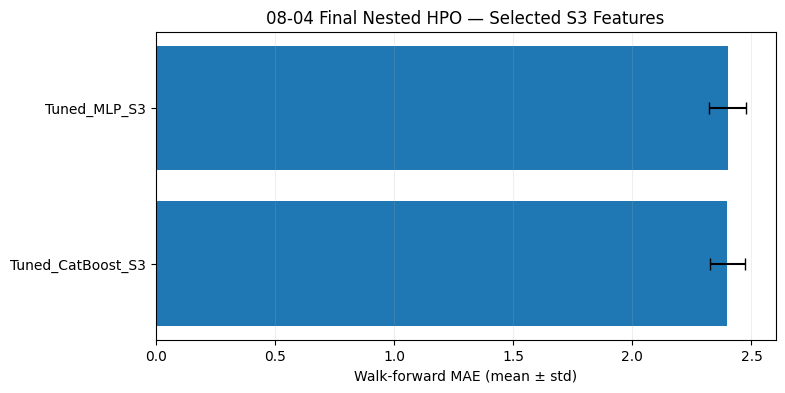

In [50]:
plot_df = (
    tuned_summary
    .sort_values(
        "mae_mean"
    )
)

plt.figure(
    figsize=(8, 4)
)

plt.barh(
    plot_df[
        "model"
    ],
    plot_df[
        "mae_mean"
    ],
    xerr=plot_df[
        "mae_std"
    ],
    capsize=4,
)

plt.xlabel(
    "Walk-forward MAE "
    "(mean ± std)"
)

plt.title(
    "08-04 Final Nested HPO — Selected S3 Features"
)

plt.grid(
    axis="x",
    alpha=0.2,
)

plt.show()

# Part K. 결과 저장

In [51]:
ARTIFACT_DIR = (
    COLAB_ARTIFACT_DIR
    if IN_COLAB
    else Path("artifacts")
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Output artifact dir:",
    ARTIFACT_DIR.resolve()
)

OUTER_RESULTS_PATH = (
    ARTIFACT_DIR
    / "08_04_final_hpo_outer_results.csv"
)

SUMMARY_PATH = (
    ARTIFACT_DIR
    / "08_04_final_hpo_summary.csv"
)

PREDICTIONS_PATH = (
    ARTIFACT_DIR
    / "08_04_final_hpo_predictions.csv"
)

CAT_TRIALS_PATH = (
    ARTIFACT_DIR
    / "08_04_catboost_optuna_trials.csv"
)

MLP_TRIALS_PATH = (
    ARTIFACT_DIR
    / "08_04_mlp_optuna_trials.csv"
)

CAT_PARAMS_PATH = (
    ARTIFACT_DIR
    / "08_04_catboost_best_params_by_fold.csv"
)

MLP_PARAMS_PATH = (
    ARTIFACT_DIR
    / "08_04_mlp_best_params_by_fold.csv"
)

HIGH_SCORER_PATH = (
    ARTIFACT_DIR
    / "08_04_high_scorer_summary.csv"
)


tuned_outer_results.to_csv(
    OUTER_RESULTS_PATH,
    index=False,
)

tuned_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

tuned_outer_predictions.to_csv(
    PREDICTIONS_PATH,
    index=False,
)

catboost_trials.to_csv(
    CAT_TRIALS_PATH,
    index=False,
)

mlp_trials.to_csv(
    MLP_TRIALS_PATH,
    index=False,
)

catboost_params_df.to_csv(
    CAT_PARAMS_PATH,
    index=False,
)

mlp_params_df.to_csv(
    MLP_PARAMS_PATH,
    index=False,
)

high_scorer_summary.to_csv(
    HIGH_SCORER_PATH,
    index=False,
)


print("Saved:")
for path in [
    OUTER_RESULTS_PATH,
    SUMMARY_PATH,
    PREDICTIONS_PATH,
    CAT_TRIALS_PATH,
    MLP_TRIALS_PATH,
    CAT_PARAMS_PATH,
    MLP_PARAMS_PATH,
    HIGH_SCORER_PATH,
]:
    print(
        "-",
        path.resolve(),
    )

Output artifact dir: /content/drive/MyDrive/next_season_goal_prediction/artifacts
Saved:
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_final_hpo_outer_results.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_final_hpo_summary.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_final_hpo_predictions.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_catboost_optuna_trials.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_mlp_optuna_trials.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_catboost_best_params_by_fold.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_mlp_best_params_by_fold.csv
- /content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_high_scorer_summary.csv


## 27. Protocol 저장

In [52]:
HPO_PROTOCOL = {
    "stage": (
        "08-04 Final Nested HPO"
    ),

    "data_min_target_year": (
        2017
    ),

    "population": (
        "matched_next == True"
    ),

    "feature_set": (
        "S3_selected_no_economics"
    ),

    "numeric_features": (
        FINAL_NUMERIC
    ),

    "categorical_features": (
        FINAL_CATEGORICAL
    ),

    "excluded_features": [
        "transfer_fee_known",
        "log_transfer_fee",
        "fee_to_transfer_market_value_ratio",
    ],

    "outer_validation_seasons": (
        OUTER_VAL_SEASONS
    ),

    "inner_folds": (
        N_INNER_FOLDS
    ),

    "catboost_trials": (
        N_TRIALS_CATBOOST
    ),

    "mlp_trials": (
        N_TRIALS_MLP
    ),

    "primary_metric": (
        "MAE"
    ),

    "mlp_loss": (
        "MSE"
    ),

    "test_input_season": (
        LOCKED_TEST_INPUT_SEASON
    ),

    "test_target_season": (
        LOCKED_TEST_TARGET_SEASON
    ),

    "test_status": (
        "LOCKED / NOT LOADED"
    ),

    "feature_reselection": (
        "NOT ALLOWED"
    ),

    "loss_experiment": (
        "NOT INCLUDED"
    ),
}

PROTOCOL_PATH = (
    ARTIFACT_DIR
    / "08_04_final_hpo_protocol.json"
)

with PROTOCOL_PATH.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        HPO_PROTOCOL,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(
    PROTOCOL_PATH.resolve()
)

/content/drive/MyDrive/next_season_goal_prediction/artifacts/08_04_final_hpo_protocol.json


# 28. 결과 해석 — 직접 작성

아래는 **의도적으로 비워둡니다.**

---

## A. CatBoost

1. 08-03 Fixed CatBoost S3 MAE `≈ 2.3826`보다 개선됐는가?
2. 4개 Outer Fold 중 몇 개에서 fixed S3보다 좋아졌는가?
3. RMSE / R²도 함께 개선됐는가?
4. 10+/15+/20+ 고득점자 성능은 개선됐는가?
5. 실제 이적 선수 MAE는 개선됐는가?
6. Best parameter가 Fold마다 크게 흔들리는가?
7. 07처럼 HPO가 baseline보다 오히려 나빠지는 현상이 반복되는가?

### 내 결론

- CatBoost HPO 효과:
- 평균 MAE:
- 안정성:
- 고득점자:
- 이적 선수:
- Hyperparameter 안정성:

---

## B. MLP

1. 08-03 Frozen MLP S3 MAE `≈ 2.4507`보다 크게 회복됐는가?
2. 기존 MLP S0 MAE `≈ 2.3738`까지 회복하는가?
3. S3에서 좋아졌던 10+/20+ 고득점 성능을 유지하는가?
4. 전체 Bias는 0 근처인가?
5. Architecture가 다시 `256_128_64`에 집중되는가?
6. dropout/lr/weight_decay가 Fold마다 크게 흔들리는가?
7. best epoch가 지나치게 짧은 Fold가 반복되는가?

### 내 결론

- MLP retuning 효과:
- 전체 MAE:
- 고득점자:
- Bias:
- 학습 안정성:
- Hyperparameter 안정성:

---

## C. 최종 모델 선택

다음 세 기준을 동시에 봅니다.

### 1. 전체 예측
- MAE
- RMSE
- R²
- Worst Fold / std

### 2. Business / Football 중요 Slice
- 10+
- 15+
- 20+
- changed_team

### 3. 운영 안정성
- Fold 간 일관성
- HPO 민감도
- 계산 비용

### 최종 결론

- 전체 MAE 1위:
- RMSE/R² 1위:
- 고득점자 1위:
- 이적 선수 1위:
- 안정성 1위:
- 최종 Model B 후보:
- 보조 Model 후보:
- 추가 HPO 필요 여부:
- Feature 실험 종료 여부:

# 다음 단계

08-04 이후에는 **HPO도 종료**하는 것을 기본 원칙으로 합니다.

다음:

# 09. Two-stage Modeling

```text
Model A
P(다음 시즌 Big5 기록 존재)

Model B
E(다음 시즌 득점 | Big5 기록 존재)
```

Model A는 전체 row를 사용하고,
Model B는 현재처럼 `matched_next=True` 조건부 회귀를 사용합니다.

---

## 고득점자 문제는 별도 연구로 분리

08-04에서도 고득점 과소예측이 강하게 남는다면
더 이상 hyperparameter 문제로 보지 않습니다.

후속 후보:

- Weighted MSE
- Poisson / Count regression
- Target transform
- Playing-time × scoring-rate decomposition
- 페널티 전담
- 역할 변화
- 부상/출전 가능성
- 감독/전술 변화

즉:

```text
Feature 문제
Model hyperparameter 문제
Objective 문제
```

를 서로 섞지 않고 순서대로 검증합니다.